# Températures et risque de pluie sur 5 jours

Les zones bleues indiquent les créneaux où l'écart entre la température et le point de rosée est inférieur ou égal à 4 °C. C'est un indicateur de risque d'humidité/nuages, pas une prévision de pluie certaine.

In [1]:
import json
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

FICHIER_METEO = Path(r'Y:/Documents/5days.txt')
SEUIL_RISQUE_PLUIE = 5  # °C : température - point de rosée

with FICHIER_METEO.open(encoding='utf-8') as fichier:
    meteo = pd.DataFrame(json.load(fichier))

colonnes = {'dt', 'temp', 'dew_point'}
manquantes = colonnes - set(meteo.columns)
if manquantes:
    raise ValueError(f'Colonnes absentes du fichier : {sorted(manquantes)}')

meteo['date'] = pd.to_datetime(meteo['dt'], unit='s', utc=True).dt.tz_convert('Europe/Paris').dt.tz_localize(None)
meteo['ecart_rosee'] = meteo['temp'] - meteo['dew_point']
meteo['risque_pluie'] = meteo['ecart_rosee'] <= SEUIL_RISQUE_PLUIE
meteo[['date', 'temp', 'dew_point', 'ecart_rosee', 'risque_pluie']]

,date,temp,dew_point,ecart_rosee,risque_pluie
0,2026-09-04 11:00:00,21.15,17.17,3.98,True
1,2026-09-04 14:00:00,25.44,16.03,9.41,False
2,2026-09-04 17:00:00,31.76,14.68,17.08,False
3,2026-09-04 20:00:00,25.92,15.66,10.26,False
4,2026-09-04 23:00:00,20.35,15.07,5.28,False
5,2026-09-05 02:00:00,16.64,10.34,6.30,False
6,2026-09-05 05:00:00,14.94,9.79,5.15,False
7,2026-09-05 08:00:00,14.99,10.30,4.69,True
8,2026-09-05 11:00:00,21.12,7.89,13.23,False
9,2026-09-05 14:00:00,23.11,4.33,18.78,False


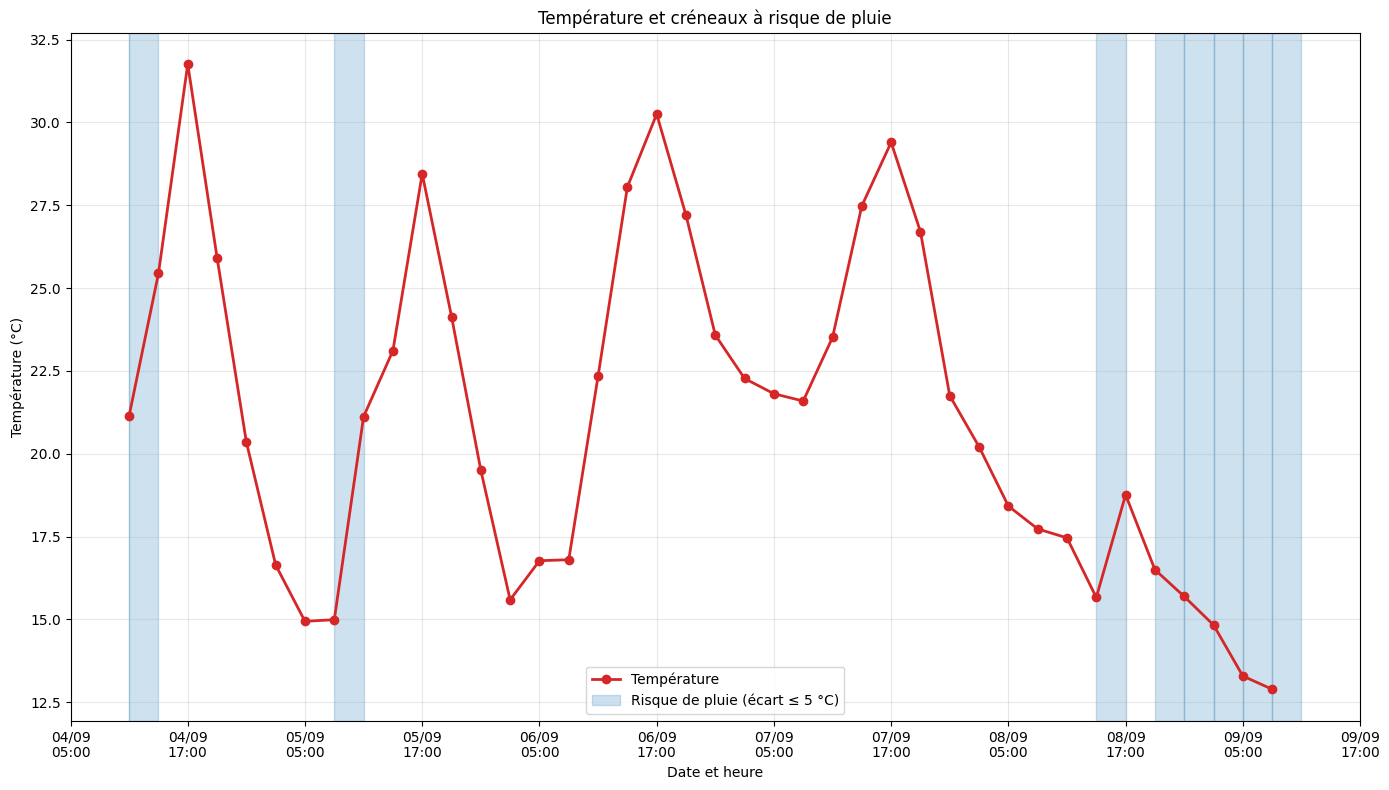

Créneaux bleus :


,date,temp,dew_point,ecart_rosee
0,2026-09-04 11:00:00,21.2,17.2,4.0
7,2026-09-05 08:00:00,15.0,10.3,4.7
33,2026-09-08 14:00:00,15.7,11.6,4.0
35,2026-09-08 20:00:00,16.5,13.2,3.3
36,2026-09-08 23:00:00,15.7,13.1,2.6
37,2026-09-09 02:00:00,14.8,11.7,3.1
38,2026-09-09 05:00:00,13.3,10.4,2.9
39,2026-09-09 08:00:00,12.9,10.2,2.7


In [3]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(meteo['date'], meteo['temp'], color='tab:red', marker='o', linewidth=2, label='Température')

# Chaque mesure couvre 3 heures dans le fichier de prévisions OpenWeather.
for _, ligne in meteo.loc[meteo['risque_pluie']].iterrows():
    ax.axvspan(ligne['date'], ligne['date'] + pd.Timedelta(hours=3), color='tab:blue', alpha=0.22)

# Entrée de légende pour les zones bleues.
ax.axvspan(meteo['date'].iloc[0], meteo['date'].iloc[0], color='tab:blue', alpha=0.22, label=f'Risque de pluie (écart ≤ {SEUIL_RISQUE_PLUIE} °C)')
ax.set_title('Température et créneaux à risque de pluie')
ax.set_xlabel('Date et heure')
ax.set_ylabel('Température (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m\n%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

print('Créneaux bleus :')
display(meteo.loc[meteo['risque_pluie'], ['date', 'temp', 'dew_point', 'ecart_rosee']].round({'temp': 1, 'dew_point': 1, 'ecart_rosee': 1}))